In [2]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for text preprocessing
import re

# Import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
# Load the IMDb dataset
df = pd.read_csv("IMDB Dataset.csv")

# Display the first five rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns)

# Check data types
print("\nData types:")
print(df.dtypes)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [5]:
# Check the number of positive and negative reviews
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


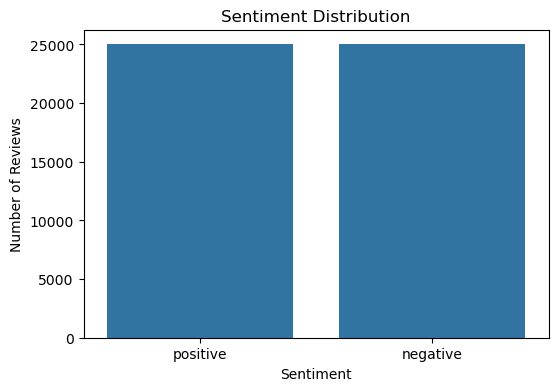

In [6]:
# Plot sentiment distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [7]:
# Check how many duplicate reviews are present
duplicate_reviews = df["review"].duplicated().sum()

print("Duplicate reviews:", duplicate_reviews)

Duplicate reviews: 418


In [8]:
# Remove duplicate reviews
df = df.drop_duplicates(subset="review").reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (49582, 2)


In [10]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create a label encoder
le = LabelEncoder()

# Convert sentiment labels into numerical labels
df["sentiment"] = le.fit_transform(df["sentiment"])

# Check the result
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [11]:
# Create a function to clean review text
def clean_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [12]:
# Apply the cleaning function to all reviews
df["clean_review"] = df["review"].apply(clean_text)

# Display original and cleaned reviews
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [13]:
# Compare one original review with its cleaned version
print("Original Review:\n")
print(df["review"].iloc[0])

print("\n\nCleaned Review:\n")
print(df["clean_review"].iloc[0])

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [14]:
# X contains the review text
X = df["clean_review"]

# y contains the sentiment label
y = df["sentiment"]

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [16]:
# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 10000)
Testing TF-IDF shape: (9917, 10000)


In [17]:
# Create the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

# Predict sentiment for test reviews
y_pred_lr = lr_model.predict(X_test_tfidf)

In [18]:
# Calculate Logistic Regression performance
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.9005
Precision: 0.8903
Recall   : 0.9144
F1 Score : 0.9022


In [19]:
# Display detailed classification results
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [20]:
# Create the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model
rf_model.fit(X_train_tfidf, y_train)

# Predict sentiment for test reviews
y_pred_rf = rf_model.predict(X_test_tfidf)

In [21]:
# Calculate Random Forest performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
---------------------
Accuracy : 0.8555
Precision: 0.8527
Recall   : 0.8608
F1 Score : 0.8567


In [22]:
# Display detailed Random Forest results
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      4940
    Positive       0.85      0.86      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



In [23]:
# Create a table to compare both models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ]
})

# Display results
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9005,0.8903,0.9144,0.9022
1,Random Forest,0.8555,0.8527,0.8608,0.8567


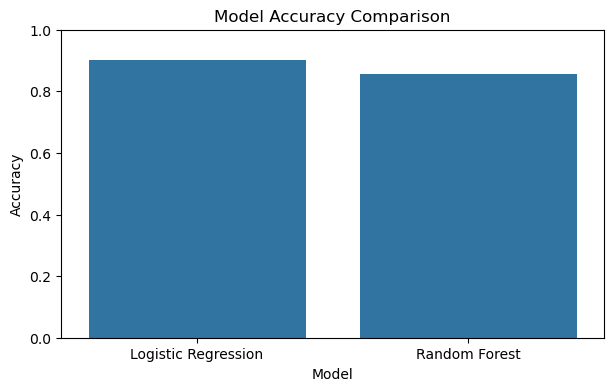

In [24]:
# Plot model accuracy comparison
plt.figure(figsize=(7, 4))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

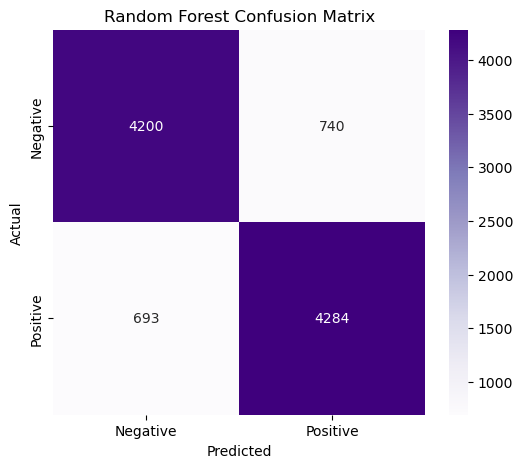

In [28]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
# Store predictions for error analysis
error_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred_rf
})

# Select incorrectly classified reviews
errors = error_df[
    error_df["actual"] != error_df["predicted"]
]

print("Number of incorrect predictions:", len(errors))

Number of incorrect predictions: 1433


In [30]:
# Display some incorrectly classified reviews
errors.head(10)

,review,actual,predicted
15,this isn t exactly a great film but i admire t...,1,0
21,when the film started i got the feeling this w...,0,1
24,despite being a huge fan of fred astaire and g...,0,1
35,well well roeg touched a bit of a nerve there ...,1,0
45,i m not here to tell you armored is kubrickian...,1,0
51,this movie probably had a budget and still man...,1,0
53,i m not a big fan of rom coms at the best of t...,0,1
77,this cecil b demille epic of the old west cont...,1,0
78,i was excited to hear that someone had made a ...,0,1
79,using tons of stock footage not only from trad...,0,1


In [33]:
# Import Linear SVM
from sklearn.svm import LinearSVC

# Create the SVM model
svm_model = LinearSVC(
    random_state=42
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predict sentiment for test reviews
y_pred_svm = svm_model.predict(X_test_tfidf)

In [ ]:
# Calculate SVM performance
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Linear SVM Results")
print("------------------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))

Linear SVM Results
------------------
Accuracy : 0.8949
Precision: 0.8905
Recall   : 0.9015
F1 Score : 0.896


In [35]:
# Display detailed SVM results
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      4940
    Positive       0.89      0.90      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.90      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [36]:
# Add SVM results to the model comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        svm_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        svm_f1
    ]
})

# Display the comparison
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9005,0.8903,0.9144,0.9022
1,Random Forest,0.8555,0.8527,0.8608,0.8567
2,Linear SVM,0.8949,0.8905,0.9015,0.8960


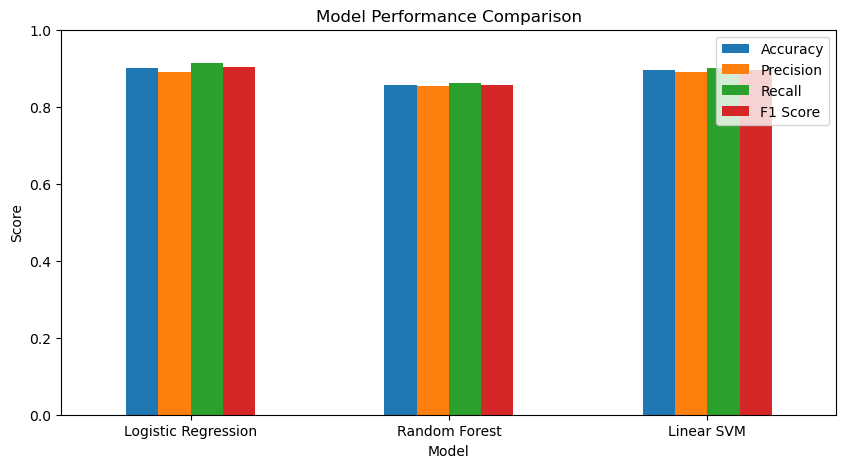

In [37]:
# Compare model performance
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

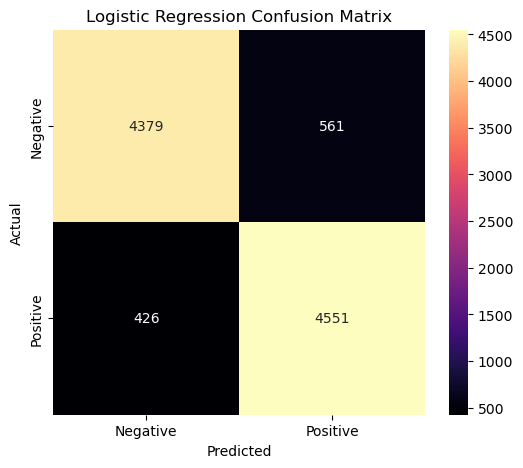

In [38]:
# Create the confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
# Create a custom review
custom_review = [
    "The movie was absolutely fantastic. The acting was brilliant and the story was amazing."
]

# Convert the review into TF-IDF features
custom_review_tfidf = tfidf.transform(custom_review)

# Predict sentiment using the best model
prediction = lr_model.predict(custom_review_tfidf)

# Convert prediction into text
if prediction[0] == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

Predicted Sentiment: Positive


In [43]:
# Create a negative review
custom_review = [
    "The movie was boring and disappointing. The acting was terrible and the story was very weak."
]

# Convert the review into TF-IDF features
custom_review_tfidf = tfidf.transform(custom_review)

# Predict sentiment using the best model
prediction = lr_model.predict(custom_review_tfidf)

# Convert prediction into text
if prediction[0] == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

Predicted Sentiment: Negative
